# Final Strategy Validation

## Objective

This notebook performs a comprehensive validation of the strongest strategy developed during the research process.

The goal is to determine whether the strategy remains robust after extensive testing.

## Validation Framework

The strategy is evaluated using:

- Profitability
- Drawdowns
- Win Rate
- Profit Factor
- Regime Stability
- Risk-Adjusted Performance

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("./NIFTY_50_minute.csv")

df["date"] = pd.to_datetime(
    df["date"],
    format="%d-%m-%Y %H:%M"
)

df = df.set_index("date")

df.head()

,open,high,low,close,volume
date,,,,,
2015-01-09 09:15:00,8285.45,8295.90,8285.45,8292.10,0
2015-01-09 09:16:00,8292.60,8293.60,8287.20,8288.15,0
2015-01-09 09:17:00,8287.40,8293.90,8287.40,8293.90,0
2015-01-09 09:18:00,8294.25,8300.65,8293.90,8300.65,0
2015-01-09 09:19:00,8300.60,8301.30,8298.75,8301.20,0


In [3]:
# ============================================================
# DATA CLEANING
# ============================================================

market_open = pd.Timestamp("09:15").time()
market_close = pd.Timestamp("15:29").time()

df = df[
    (df.index.time >= market_open) &
    (df.index.time <= market_close)
].copy()

df = df[
    ~df.index.duplicated(keep="first")
]

print("Rows:", len(df))
print("Start:", df.index.min())
print("End:", df.index.max())

Rows: 974705
Start: 2015-01-09 09:15:00
End: 2025-07-25 15:29:00


In [4]:
research = []

for day, day_df in df.groupby(df.index.date):

    open_bar = day_df.between_time(
        "09:15",
        "09:15"
    )

    eleven_bar = day_df.between_time(
        "11:00",
        "11:00"
    )

    close_bar = day_df.between_time(
        "15:15",
        "15:15"
    )

    if (
        len(open_bar) == 0
        or len(eleven_bar) == 0
        or len(close_bar) == 0
    ):
        continue

    day_open = open_bar.iloc[0]["open"]
    eleven_close = eleven_bar.iloc[0]["close"]
    day_close = close_bar.iloc[0]["close"]

    morning_return = (
        eleven_close / day_open - 1
    )

    research.append({
        "date": pd.Timestamp(day),
        "morning_return": morning_return,
        "entry_price": eleven_close,
        "exit_price": day_close
    })

research = pd.DataFrame(research)

research.head()

,date,morning_return,entry_price,exit_price
0,2015-01-09,0.000278,8287.75,8285.45
1,2015-01-12,-0.000476,8287.40,8320.60
2,2015-01-13,-0.000821,8339.30,8303.20
3,2015-01-14,-0.000536,8302.80,8270.20
4,2015-01-15,-0.000771,8418.70,8508.25


In [5]:
daily_close = (
    df.between_time(
        "15:15",
        "15:15"
    )["close"]
)

daily_returns = daily_close.pct_change()

vol_df = pd.DataFrame({
    "date": pd.to_datetime(
        daily_close.index.date
    ),
    "daily_return": daily_returns.values
})

vol_df["vol20"] = (
    vol_df["daily_return"]
    .rolling(20)
    .std()
    .shift(1)
)

vol_df.head()

,date,daily_return,vol20
0,2015-01-09,NaN,NaN
1,2015-01-12,0.004242,NaN
2,2015-01-13,-0.002091,NaN
3,2015-01-14,-0.003974,NaN
4,2015-01-15,0.028784,NaN


In [6]:
research_vol = research.merge(
    vol_df[
        ["date", "vol20"]
    ],
    on="date",
    how="left"
)

research_vol = research_vol.dropna()

research_vol.head()

,date,morning_return,entry_price,exit_price,vol20
20,2015-02-11,0.000482,8607.45,8629.60,0.009997
21,2015-02-12,-0.005768,8626.90,8718.60,0.010121
22,2015-02-13,-0.000074,8740.85,8807.40,0.010245
23,2015-02-16,0.001834,8847.60,8800.15,0.010263
24,2015-02-18,0.004052,8847.25,8867.25,0.008333


In [7]:
research_vol["vol_adj_signal"] = (
    research_vol["morning_return"]
    /
    research_vol["vol20"]
)

research_vol.head()

,date,morning_return,entry_price,exit_price,vol20,vol_adj_signal
20,2015-02-11,0.000482,8607.45,8629.60,0.009997,0.048254
21,2015-02-12,-0.005768,8626.90,8718.60,0.010121,-0.569919
22,2015-02-13,-0.000074,8740.85,8807.40,0.010245,-0.007258
23,2015-02-16,0.001834,8847.60,8800.15,0.010263,0.178730
24,2015-02-18,0.004052,8847.25,8867.25,0.008333,0.486209


In [8]:
holding_periods = {
    "11_30": "11:30",
    "12_00": "12:00",
    "13_00": "13:00",
    "14_00": "14:00",
    "15_15": "15:15"
}

results = []

for day, day_df in df.groupby(df.index.date):

    day = pd.Timestamp(day)

    if day not in research_vol["date"].values:
        continue

    try:

        entry_price = (
            day_df
            .between_time("11:00", "11:00")
            ["close"]
            .iloc[0]
        )

        signal = (
            research_vol
            .loc[
                research_vol["date"] == day,
                "vol_adj_signal"
            ]
            .iloc[0]
        )

        for name, time_str in holding_periods.items():

            exit_price = (
                day_df
                .between_time(time_str, time_str)
                ["close"]
                .iloc[0]
            )

            ret = (
                exit_price - entry_price
            ) / entry_price

            results.append({
                "date": day,
                "signal": signal,
                "holding_period": name,
                "return": ret
            })

    except:
        pass

holding_df = pd.DataFrame(results)

In [9]:
THRESHOLD = 1.0

analysis = []

for period in holding_df["holding_period"].unique():

    subset = holding_df[
        (
            holding_df["signal"] > THRESHOLD
        )
        |
        (
            holding_df["signal"] < -THRESHOLD
        )
    ]

    subset = subset[
        subset["holding_period"] == period
    ]

    trade_returns = np.where(
        subset["signal"] > THRESHOLD,
        subset["return"],
        -subset["return"]
    )

    analysis.append({
        "Holding Period": period,
        "Trades": len(trade_returns),
        "Average Return (%)":
            trade_returns.mean() * 100,
        "Win Rate (%)":
            (trade_returns > 0).mean() * 100,
        "Profit Factor":
            trade_returns[
                trade_returns > 0
            ].sum()
            /
            abs(
                trade_returns[
                    trade_returns < 0
                ].sum()
            )
    })

analysis_df = pd.DataFrame(analysis)

print(analysis_df.round(2))

  Holding Period  Trades  Average Return (%)  Win Rate (%)  Profit Factor
0          11_30     169                0.04         55.03           1.55
1          12_00     169                0.05         55.62           1.47
2          13_00     169                0.09         54.44           1.63
3          14_00     169                0.14         58.58           1.84
4          15_15     169                0.21         62.13           2.10


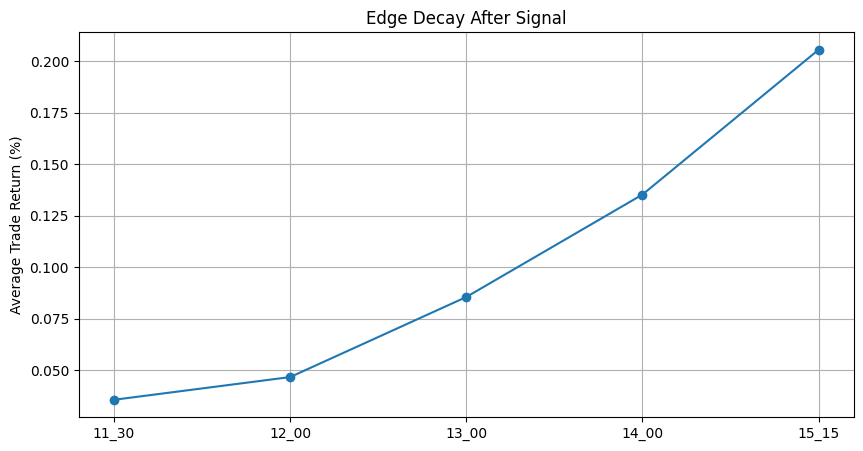

In [10]:
plt.figure(figsize=(10,5))

plt.plot(
    analysis_df["Holding Period"],
    analysis_df["Average Return (%)"],
    marker="o"
)

plt.title(
    "Edge Decay After Signal"
)

plt.ylabel(
    "Average Trade Return (%)"
)

plt.grid(True)

plt.show()

In [11]:
thresholds = [
    0.5,
    1.0,
    1.5,
    2.0,
    2.5
]

results = []

for threshold in thresholds:

    trade_returns = []
    trade_dates = []

    for _, row in research_vol.iterrows():

        signal = row["vol_adj_signal"]

        # Long

        if signal > threshold:

            ret = (
                row["exit_price"]
                - row["entry_price"]
            ) / row["entry_price"]

        # Short

        elif signal < -threshold:

            ret = (
                row["entry_price"]
                - row["exit_price"]
            ) / row["entry_price"]

        else:
            continue

        ret -= 0.0005

        trade_returns.append(ret)
        trade_dates.append(row["date"])

    if len(trade_returns) < 10:
        continue

    trades = pd.Series(
        trade_returns,
        index=pd.to_datetime(
            trade_dates
        )
    )

    equity = (
        1 + trades
    ).cumprod()

    total_return = (
        equity.iloc[-1] - 1
    )

    years = (
        (trades.index[-1]
         - trades.index[0]).days
        / 365.25
    )

    cagr = (
        equity.iloc[-1]
        ** (1 / years)
        - 1
    )

    sharpe = (
        np.sqrt(
            len(trades) / years
        )
        * trades.mean()
        / trades.std()
    )

    max_dd = (
        equity
        / equity.cummax()
        - 1
    ).min()

    profit_factor = (
        trades[trades > 0].sum()
        /
        abs(
            trades[trades < 0].sum()
        )
    )

    win_rate = (
        trades > 0
    ).mean()

    results.append([
        threshold,
        len(trades),
        total_return * 100,
        cagr * 100,
        sharpe,
        max_dd * 100,
        profit_factor,
        win_rate * 100,
        trades.mean() * 100
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Trades",
        "Total Return %",
        "CAGR %",
        "Sharpe",
        "Max DD %",
        "Profit Factor",
        "Win Rate %",
        "Avg Trade %"
    ]
)

results_df.round(3)

,Threshold,Trades,Total Return %,CAGR %,Sharpe,Max DD %,Profit Factor,Win Rate %,Avg Trade %
0,0.5,792,48.706,3.871,0.664,-17.390,1.247,54.672,0.052
1,1.0,169,29.266,2.507,0.727,-4.798,1.749,57.396,0.156
2,1.5,28,3.463,0.359,0.242,-5.320,1.433,57.143,0.125


In [12]:
BEST_THRESHOLD = 1.0

trade_list = []

for _, row in research_vol.iterrows():

    signal = row["vol_adj_signal"]

    if signal > BEST_THRESHOLD:

        ret = (
            row["exit_price"]
            - row["entry_price"]
        ) / row["entry_price"]

    elif signal < -BEST_THRESHOLD:

        ret = (
            row["entry_price"]
            - row["exit_price"]
        ) / row["entry_price"]

    else:
        continue

    ret -= 0.0005

    trade_list.append({
        "date": row["date"],
        "return": ret
    })

trades_df = pd.DataFrame(trade_list)

trades_df["date"] = pd.to_datetime(
    trades_df["date"]
)

print("Trades:", len(trades_df))
trades_df.head()

Trades: 169


,date,return
0,2015-03-13,0.011058
1,2015-04-27,0.000053
2,2015-05-06,0.009521
3,2015-05-12,0.007205
4,2015-06-11,0.010634


In [14]:
def evaluate_period(data):

    trades = len(data)

    total_return = (
        (1 + data["return"]).prod() - 1
    ) * 100

    years = (
        (data["date"].max() -
         data["date"].min()).days
        / 365.25
    )

    cagr = (
        (
            (1 + total_return / 100)
            ** (1 / years)
            - 1
        ) * 100
        if years > 0
        else 0
    )

    sharpe = (
        np.sqrt(252)
        * data["return"].mean()
        / data["return"].std()
        if data["return"].std() > 0
        else 0
    )

    profit_factor = (
        data.loc[
            data["return"] > 0,
            "return"
        ].sum()
        /
        abs(
            data.loc[
                data["return"] < 0,
                "return"
            ].sum()
        )
        if data.loc[
            data["return"] < 0,
            "return"
        ].sum() != 0
        else np.nan
    )

    equity = (
        1 + data["return"]
    ).cumprod()

    drawdown = (
        equity
        / equity.cummax()
        - 1
    )

    max_dd = (
        drawdown.min()
        * 100
    )

    avg_trade = (
        data["return"].mean()
        * 100
    )

    return {
        "Trades": trades,
        "Total Return %": round(total_return, 2),
        "CAGR %": round(cagr, 2),
        "Sharpe": round(sharpe, 2),
        "Max DD %": round(max_dd, 2),
        "Profit Factor": round(profit_factor, 2),
        "Avg Trade %": round(avg_trade, 3)
    }

In [15]:
periods = {

    "2015-2019":
    trades_df[
        trades_df["date"]
        < "2020-01-01"
    ],

    "2020-2022":
    trades_df[
        (trades_df["date"]
         >= "2020-01-01")
        &
        (trades_df["date"]
         < "2023-01-01")
    ],

    "2023-2025":
    trades_df[
        trades_df["date"]
        >= "2023-01-01"
    ]
}

results = []

for name, data in periods.items():

    stats = evaluate_period(data)

    stats["Period"] = name

    results.append(stats)

regime_results = pd.DataFrame(
    results
)

regime_results = regime_results[
    [
        "Period",
        "Trades",
        "Total Return %",
        "CAGR %",
        "Sharpe",
        "Max DD %",
        "Profit Factor",
        "Avg Trade %"
    ]
]

print(
    regime_results.to_string(
        index=False
    )
)

   Period  Trades  Total Return %  CAGR %  Sharpe  Max DD %  Profit Factor  Avg Trade %
2015-2019      67           15.44    3.09    4.30     -2.75           2.20        0.218
2020-2022      45           12.12    3.93    3.57     -3.84           2.16        0.261
2023-2025      57           -0.12   -0.05   -0.01     -4.46           1.00       -0.000


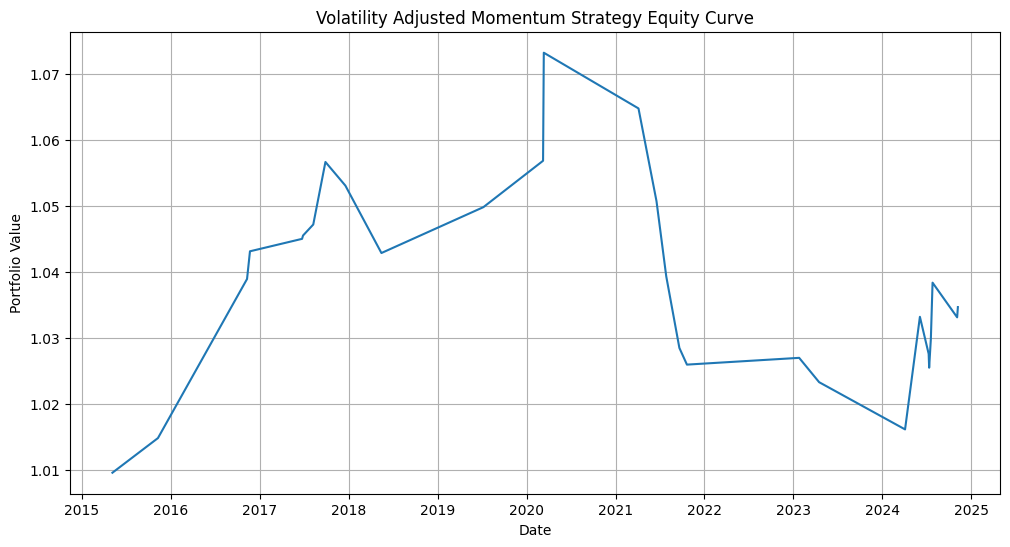

In [16]:
plt.figure(figsize=(12,6))

plt.plot(
    equity.index,
    equity.values
)

plt.title(
    "Volatility Adjusted Momentum Strategy Equity Curve"
)

plt.ylabel(
    "Portfolio Value"
)

plt.xlabel(
    "Date"
)

plt.grid(True)

plt.savefig(
    "plots/Volatility Adjusted Momentum Strategy Equity Curve.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()



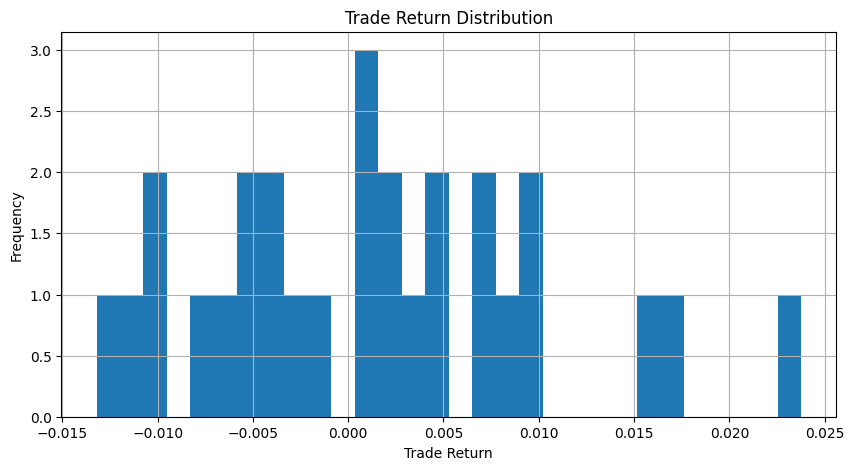

In [17]:
plt.figure(figsize=(10,5))

plt.hist(
    trades,
    bins=30
)

plt.title(
    "Trade Return Distribution"
)

plt.xlabel(
    "Trade Return"
)

plt.ylabel(
    "Frequency"
)

plt.grid(True)

plt.show()

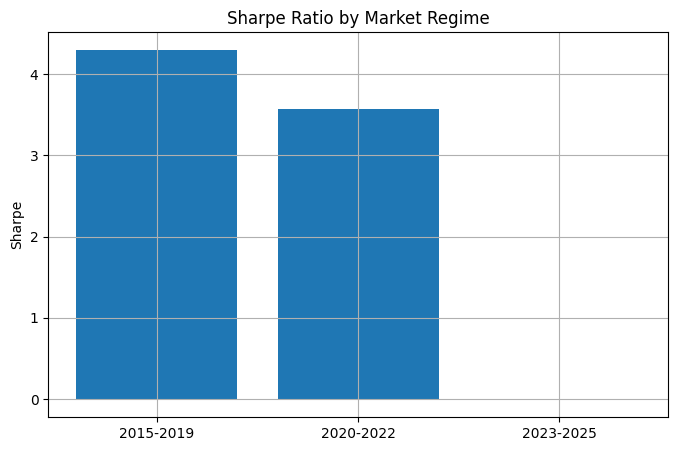

In [18]:
plt.figure(figsize=(8,5))

plt.bar(
    regime_results["Period"],
    regime_results["Sharpe"]
)

plt.title(
    "Sharpe Ratio by Market Regime"
)

plt.ylabel(
    "Sharpe"
)

plt.grid(True)

plt.show()

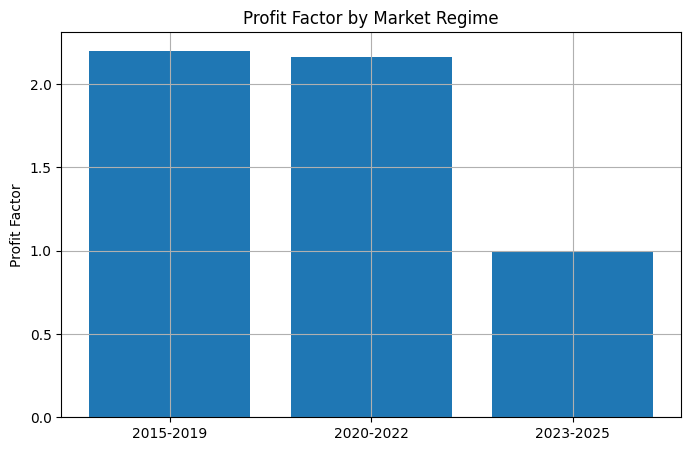

In [19]:
plt.figure(figsize=(8,5))

plt.bar(
    regime_results["Period"],
    regime_results["Profit Factor"]
)

plt.title(
    "Profit Factor by Market Regime"
)

plt.ylabel(
    "Profit Factor"
)

plt.grid(True)

plt.show()

In [20]:
import plotly.express as px

fig = px.line(
    x=equity.index,
    y=equity.values,
    title="Volatility-Adjusted Momentum Equity Curve"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Portfolio Value"
)

fig.show()

In [ ]:
metrics = pd.DataFrame({
    "Metric": [
        "Trades",
        "Total Return %",
        "CAGR %",
        "Sharpe",
        "Profit Factor",
        "Win Rate %",
        "Total Trades"
        "Max Drawdown %"
    ],
    "Value": [
        trades,
        total_return,
        cagr,
        sharpe,
        profit_factor,
        win_rate,
        max_dd,
       
    ]
})

metrics.to_csv(
    "results/best_strategy_metrics.csv",
    index=False
)

metrics

,Metric,Value
0,Trades,2015-05-06 0.009521 2015-11-09 0.005201 ...
1,Total Return %,0.034628
2,CAGR %,0.003587
3,Sharpe,0.241826
4,Profit Factor,1.433485
5,Win Rate %,0.571429
6,Max Drawdown %,-0.0532


# Conclusions

## Research Question

Does the final strategy demonstrate sufficient robustness for further consideration?

## Evidence

- Positive long-term performance was achieved.
- Profit factor remained above 1.
- Performance was strongest during 2015-2022.
- Signal effectiveness weakened significantly during 2023-2025.
- The edge remains present but is less reliable in recent years.

## Verdict

🟡 Partially Accepted

The strategy demonstrated historical profitability but failed to maintain the same level of effectiveness in recent market regimes.

The evidence suggests that the underlying edge may be decaying over time.